# Netflix Content Analysis

This project analyzes a Netflix-style content dataset using Python. The goal is to understand content distribution, genre trends, country contribution, popularity patterns, and IMDb score performance.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** `netflix_github_analysis_dataset.csv`

## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("netflix_github_analysis_dataset.csv")

df.head()

,show_id,type,title,director,cast,country,language,date_added,release_year,rating,duration,runtime_minutes,listed_in,imdb_score,popularity_score,netflix_original,description
0,n00001,Movie,Stranger Things,Ryan Murphy,"Dev Patel, Regé-Jean Page, Florence Pugh",Japan,Japanese,2016-09-24,2009,TV-14,107 min,107.0,"Reality TV, Horror",8.1,75,False,"Stranger Things is a movie in the Reality TV, ..."
1,n00002,TV Show,Wednesday,Martin Scorsese,"Kiara Advani, Scarlett Johansson, Regé-Jean Page",France,French,2020-01-28,2020,TV-MA,3 Seasons,NaN,"Mystery, Action, Horror",8.3,86,False,"Wednesday is a tv show in the Mystery, Action,..."
2,n00003,Movie,Bridgerton,Alfonso Cuarón,"Millie Bobby Brown, Ryan Reynolds, Úrsula Corberó",Japan,Japanese,2018-03-21,2018,TV-MA,174 min,174.0,History,9.2,78,True,Bridgerton is a movie in the History category ...
3,n00004,TV Show,The Queen's Gambit,Lana Wachowski,"Kriti Sanon, Regé-Jean Page, Henry Cavill",United States,Spanish,2022-09-08,2022,TV-MA,2 Seasons,NaN,"Documentary, War",7.9,81,False,The Queen's Gambit is a tv show in the Documen...
4,n00005,Movie,Squid Game,Lana Wachowski,"Rajkummar Rao, Vicky Kaushal, Radhika Apte",United States,English,2019-03-13,2019,TV-14,75 min,75.0,"War, Crime",7.8,89,False,"Squid Game is a movie in the War, Crime catego..."


## 2. Dataset Overview

Before analysis, we inspect the size, columns, missing values, duplicates, and basic statistics of the dataset.

In [2]:
print("Dataset Shape:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())

Dataset Shape: (2000, 17)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'language', 'date_added', 'release_year', 'rating', 'duration', 'runtime_minutes', 'listed_in', 'imdb_score', 'popularity_score', 'netflix_original', 'description']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   show_id           2000 non-null   object 
 1   type              2000 non-null   object 
 2   title             2000 non-null   object 
 3   director          2000 non-null   object 
 4   cast              2000 non-null   object 
 5   country           2000 non-null   object 
 6   language          2000 non-null   object 
 7   date_added        2000 non-null   object 
 8   release_year      2000 non-null   int64  
 9   rating            2000 non-null   object 
 10  duration          2000 non-null   object 
 11  runtime_minutes   1355 non-null   float64
 12  listed_in         2000 non-null   object 
 13  imdb_score        2000 non-null   float64
 14  popularity_score  2000 non-null   int64  
 15  netflix_original  2000 non-null   bool   
 16  description       2000 non-null   object 


In [4]:
# Check missing values and duplicates
missing_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()

print("Missing Values:")
print(missing_values)
print()
print("Duplicate Rows:", duplicate_rows)

Missing Values:
show_id               0
type                  0
title                 0
director              0
cast                  0
country               0
language              0
date_added            0
release_year          0
rating                0
duration              0
runtime_minutes     645
listed_in             0
imdb_score            0
popularity_score      0
netflix_original      0
description           0
dtype: int64

Duplicate Rows: 0


In [5]:
df.describe()

,release_year,runtime_minutes,imdb_score,popularity_score
count,2000.000000,1355.000000,2000.000000,2000.00000
mean,2015.219500,129.233210,7.104350,74.87050
std,7.235433,32.883891,0.857096,13.70703
min,1995.000000,75.000000,4.600000,35.00000
25%,2012.000000,100.000000,6.500000,66.00000
50%,2018.000000,128.000000,7.100000,75.00000
75%,2021.000000,159.000000,7.700000,85.00000
max,2024.000000,185.000000,9.400000,100.00000


## 3. Data Cleaning

The `date_added` column is converted into datetime format. New columns are created for year and month-level analysis.

In [6]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2016-09-24,2016,September
1,2020-01-28,2020,January
2,2018-03-21,2018,March
3,2022-09-08,2022,September
4,2019-03-13,2019,March


## 4. Exploratory Data Analysis

### Question 1: Does Netflix have more Movies or TV Shows?

This helps understand the overall composition of the content library.

In [7]:
type_counts = df['type'].value_counts()
type_percentage = df['type'].value_counts(normalize=True) * 100

type_summary = pd.DataFrame({
    'count': type_counts,
    'percentage': type_percentage.round(2)
})

type_summary

,count,percentage
type,,
Movie,1355,67.75
TV Show,645,32.25


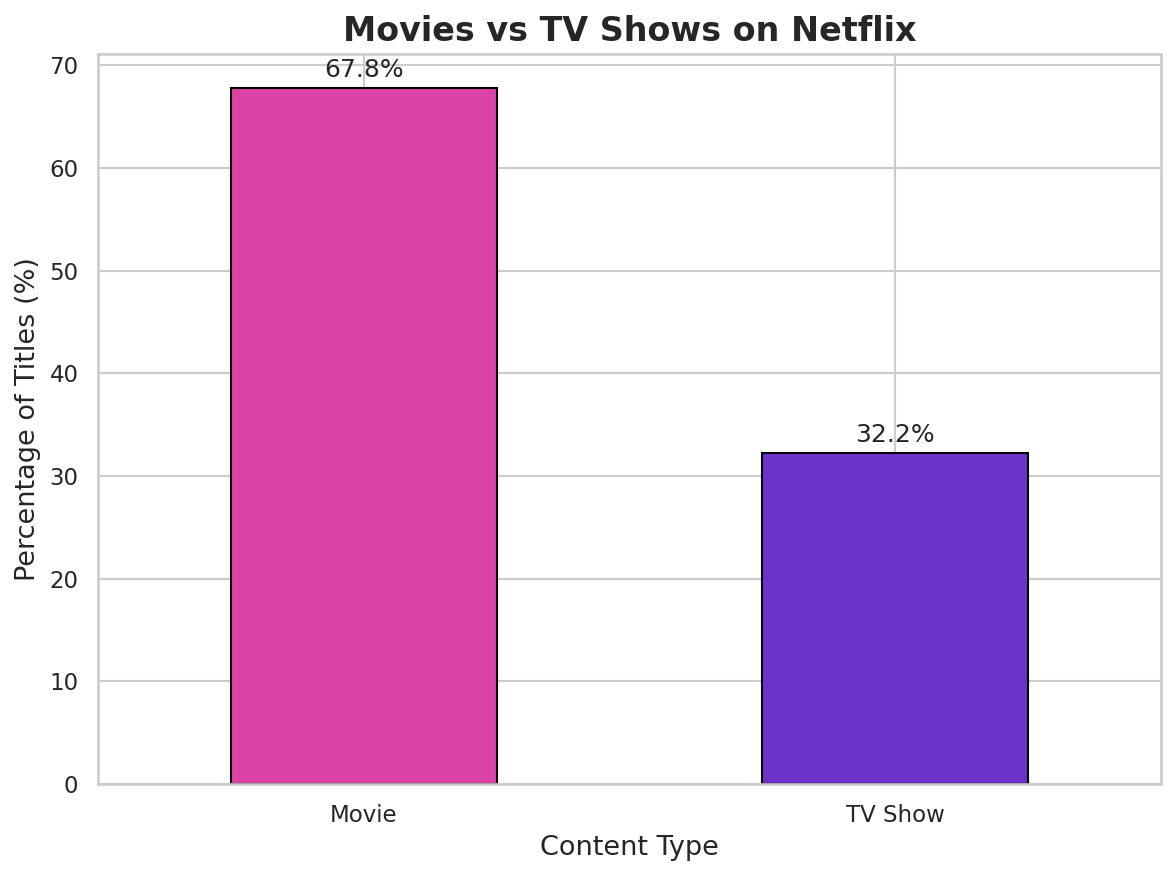

In [8]:
plt.figure(figsize=(8, 6), dpi=150)

ax = type_percentage.plot(
    kind='bar',
    color=["#DB43A5", "#6C32C9"],
    edgecolor='black'
)

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

plt.title("Movies vs TV Shows on Netflix", fontsize=16, fontweight='bold')
plt.xlabel("Content Type", fontsize=13)
plt.ylabel("Percentage of Titles (%)", fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** The chart shows whether the Netflix catalog is more movie-focused or TV-show-focused. This gives a quick overview of the platform's content strategy.

### Question 2: Which genres are most popular on Netflix?

The `listed_in` column contains multiple genres in one cell, so it needs to be split and exploded before counting genres.

In [9]:
genres = df['listed_in'].str.split(',').explode().str.strip()

genre_count = genres.value_counts().head(10)
genre_count

listed_in
Drama          253
Action         239
Crime          236
Mystery        236
Romance        227
Documentary    227
Fantasy        226
Family         225
Horror         224
Reality TV     223
Name: count, dtype: int64

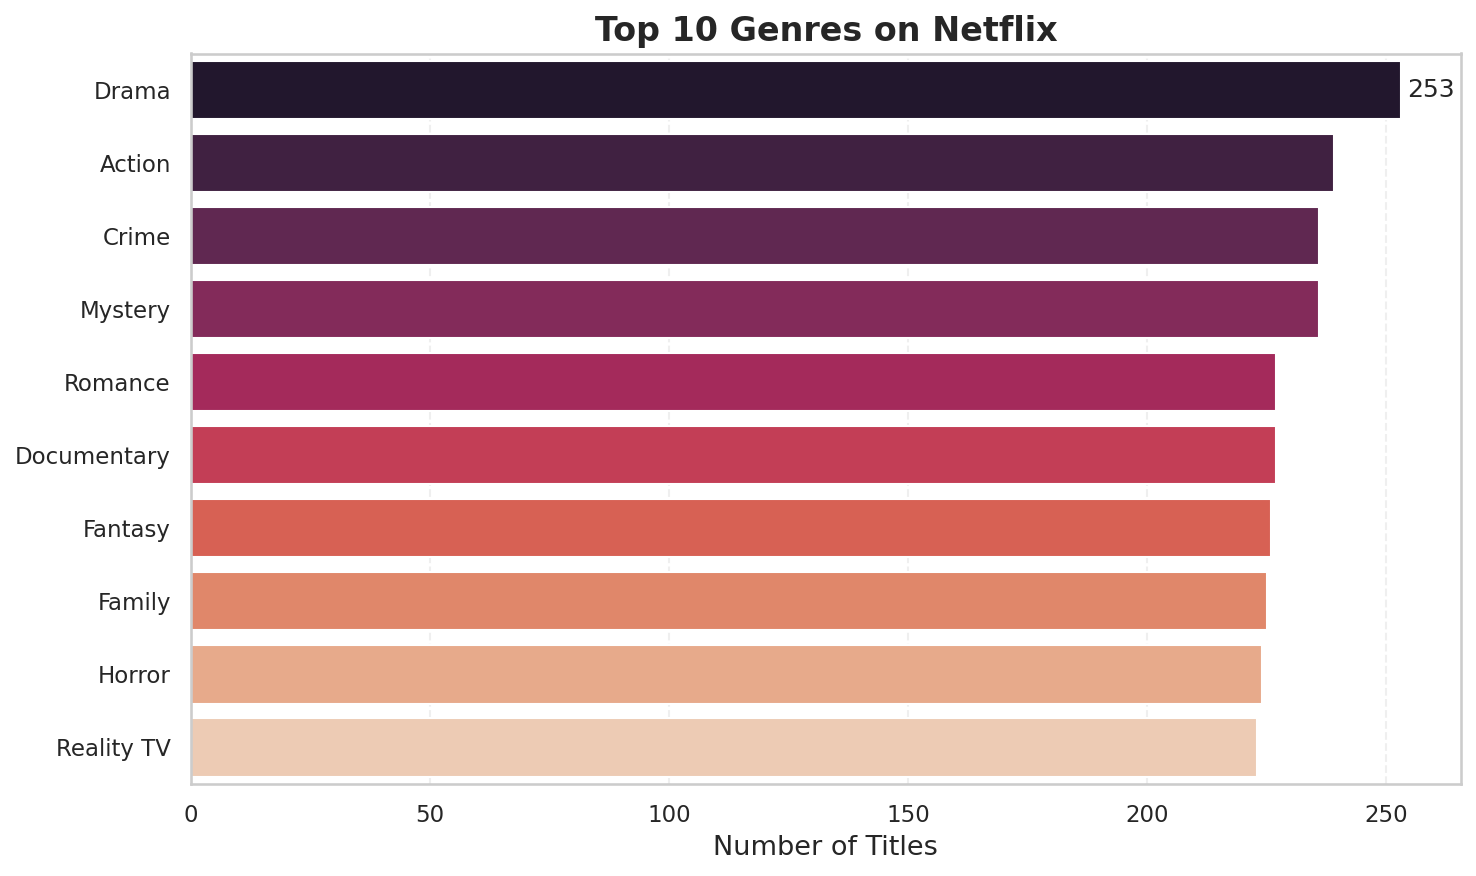

In [10]:
plt.figure(figsize=(10, 6), dpi=150)

ax = sns.barplot(
    x=genre_count.values,
    y=genre_count.index,
    hue=genre_count.index,
    palette="rocket",
    legend=False
)

ax.bar_label(ax.containers[0], padding=3)

plt.title("Top 10 Genres on Netflix", fontsize=16, fontweight='bold')
plt.xlabel("Number of Titles", fontsize=13)
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** The most frequent genres reveal the type of content Netflix offers most often and help identify dominant audience categories.

### Question 3: Which genres perform best by IMDb score and popularity?

This analysis compares genres using three metrics:

- Number of titles
- Average IMDb score
- Average popularity score

In [11]:
genre_analysis = df.copy()

genre_analysis['listed_in'] = genre_analysis['listed_in'].str.split(',')
genre_analysis = genre_analysis.explode('listed_in')
genre_analysis['listed_in'] = genre_analysis['listed_in'].str.strip()

genre_performance = genre_analysis.groupby('listed_in').agg(
    title_count=('title', 'count'),
    avg_imdb_score=('imdb_score', 'mean'),
    avg_popularity=('popularity_score', 'mean')
).sort_values(by='avg_imdb_score', ascending=False)

genre_performance.round(2)

,title_count,avg_imdb_score,avg_popularity
listed_in,,,
Horror,224,7.22,74.97
Crime,236,7.17,76.68
Action,239,7.16,74.63
Sports,216,7.16,76.02
War,220,7.16,74.10
Romance,227,7.14,76.56
Thriller,216,7.11,75.18
Sci-Fi,206,7.09,75.81
Reality TV,223,7.09,74.39


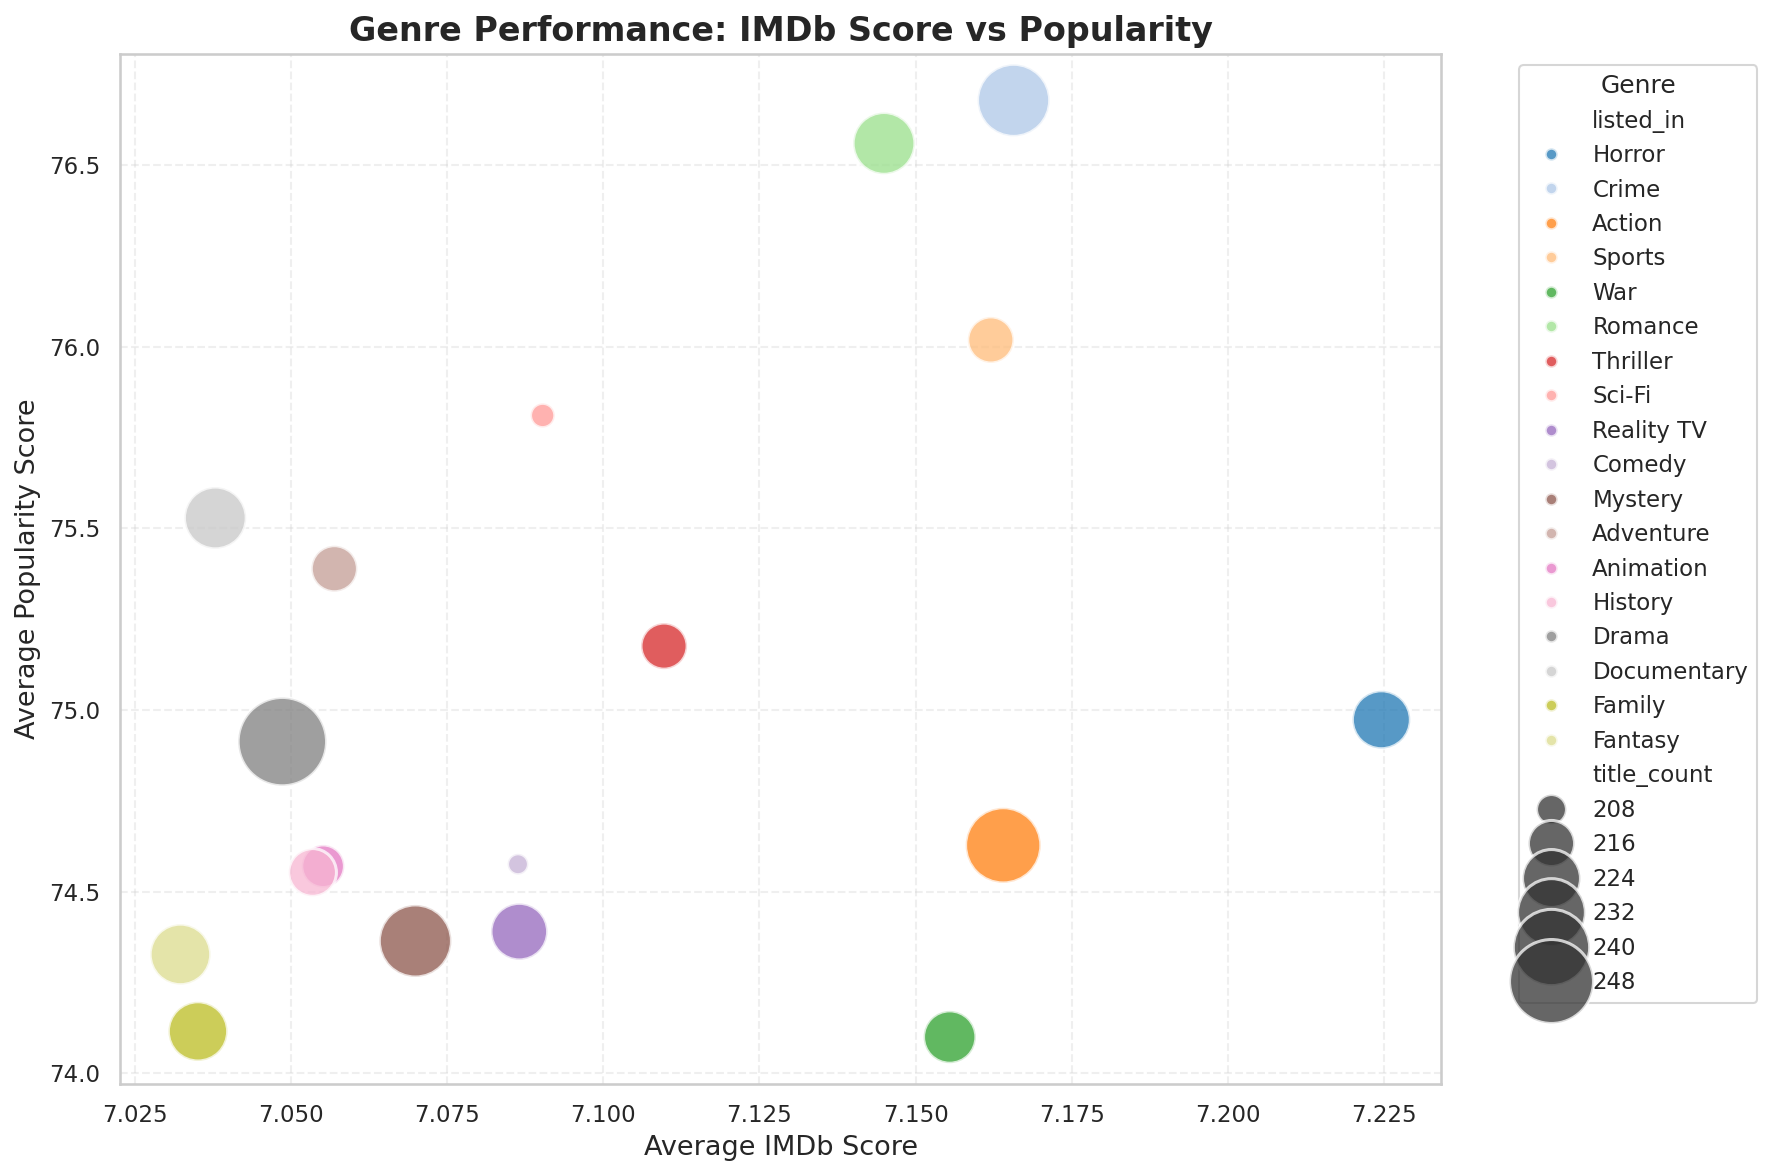

In [12]:
plt.figure(figsize=(12, 8), dpi=150)

ax = sns.scatterplot(
    data=genre_performance.reset_index(),
    x='avg_imdb_score',
    y='avg_popularity',
    size='title_count',
    hue='listed_in',
    sizes=(100, 1800),
    alpha=0.75,
    palette='tab20'
)

plt.title("Genre Performance: IMDb Score vs Popularity", fontsize=16, fontweight='bold')
plt.xlabel("Average IMDb Score", fontsize=13)
plt.ylabel("Average Popularity Score", fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Genre')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Genres positioned higher and further right perform better in both popularity and IMDb score. Larger bubbles represent genres with more titles.

### Question 4: Which countries contribute the most Movies and TV Shows?

This compares the top countries for Movies and TV Shows separately.

In [13]:
country_analysis = df.copy()

country_analysis['country'] = country_analysis['country'].str.split(',')
country_analysis = country_analysis.explode('country')
country_analysis['country'] = country_analysis['country'].str.strip()

country_group = (
    country_analysis
    .groupby(['country', 'type'])
    .size()
    .reset_index(name='count')
)

country_group.head()

,country,type,count
0,Australia,Movie,27
1,Australia,TV Show,15
2,Brazil,Movie,36
3,Brazil,TV Show,18
4,Canada,Movie,60


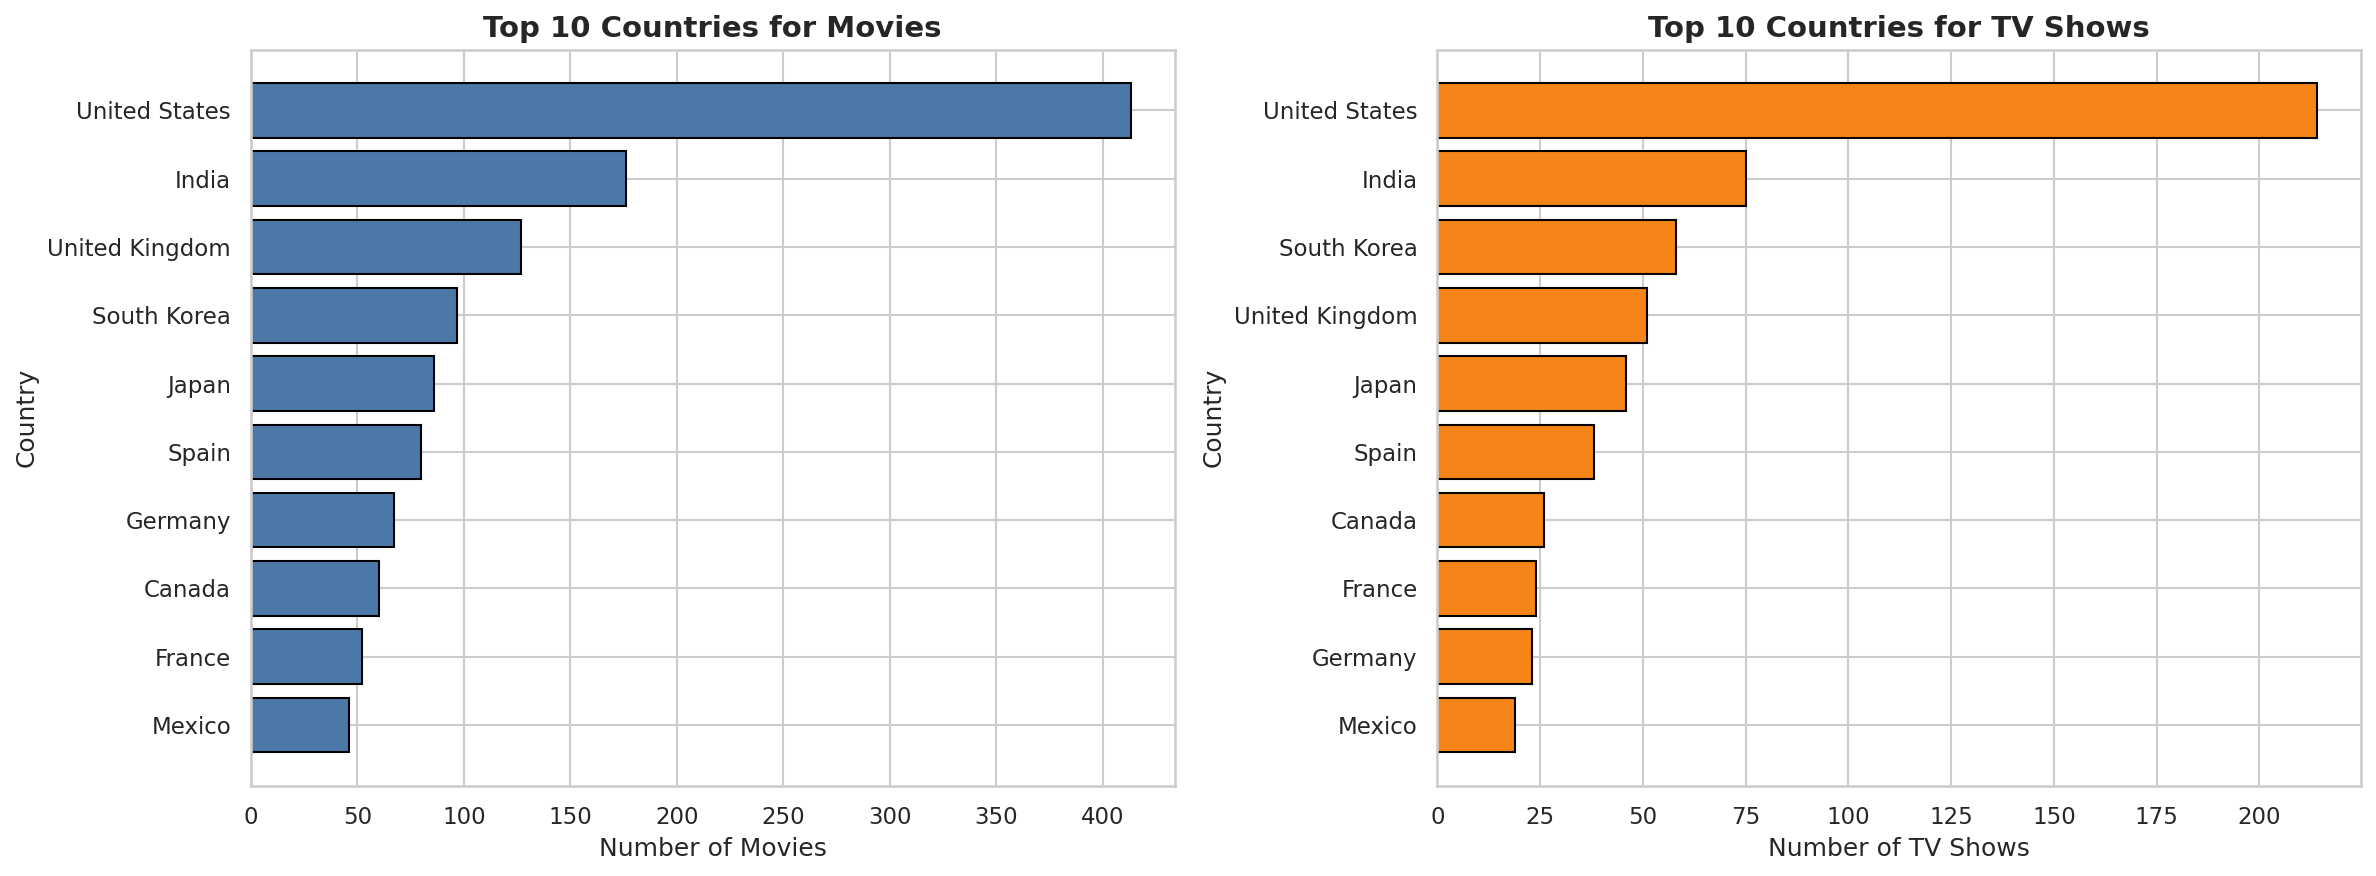

In [14]:
top_movies = (
    country_group[country_group['type'] == 'Movie']
    .sort_values(by='count', ascending=False)
    .head(10)
)

top_tvshows = (
    country_group[country_group['type'] == 'TV Show']
    .sort_values(by='count', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

ax[0].barh(top_movies['country'], top_movies['count'], color='#4C78A8', edgecolor='black')
ax[0].set_title('Top 10 Countries for Movies', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Number of Movies')
ax[0].set_ylabel('Country')
ax[0].invert_yaxis()

ax[1].barh(top_tvshows['country'], top_tvshows['count'], color='#F58518', edgecolor='black')
ax[1].set_title('Top 10 Countries for TV Shows', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Number of TV Shows')
ax[1].set_ylabel('Country')
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:** This comparison shows whether the same countries dominate both movies and TV shows or whether different regions specialize in different content formats.

### Question 5: What are the Top 10 most popular Netflix titles?

This identifies the titles with the highest popularity scores.

In [15]:
top10_titles = (
    df[['title', 'type', 'country', 'release_year', 'imdb_score', 'popularity_score']]
    .sort_values(by='popularity_score', ascending=False)
    .head(10)
)

top10_titles

,title,type,country,release_year,imdb_score,popularity_score
1939,War of Love 1940,TV Show,Japan,2002,6.7,100
1970,The Queen's Gambit: The Final Chapter,Movie,Australia,1998,6.0,100
40,House of Cards,Movie,United States,2018,7.3,100
42,Cobra Kai,Movie,United States,2013,7.1,100
27,The Adam Project,Movie,Spain,2018,9.1,100
31,The Trial of the Chicago 7,TV Show,United States,2022,7.3,100
359,War of Mystery 360,TV Show,Mexico,2020,6.7,100
1264,Club of Dream 1265,Movie,South Korea,2023,8.6,100
1739,Night of Diary 1740,Movie,United Kingdom,2016,4.8,100
1742,Diary of Shadow 1743,TV Show,Japan,2007,7.7,100


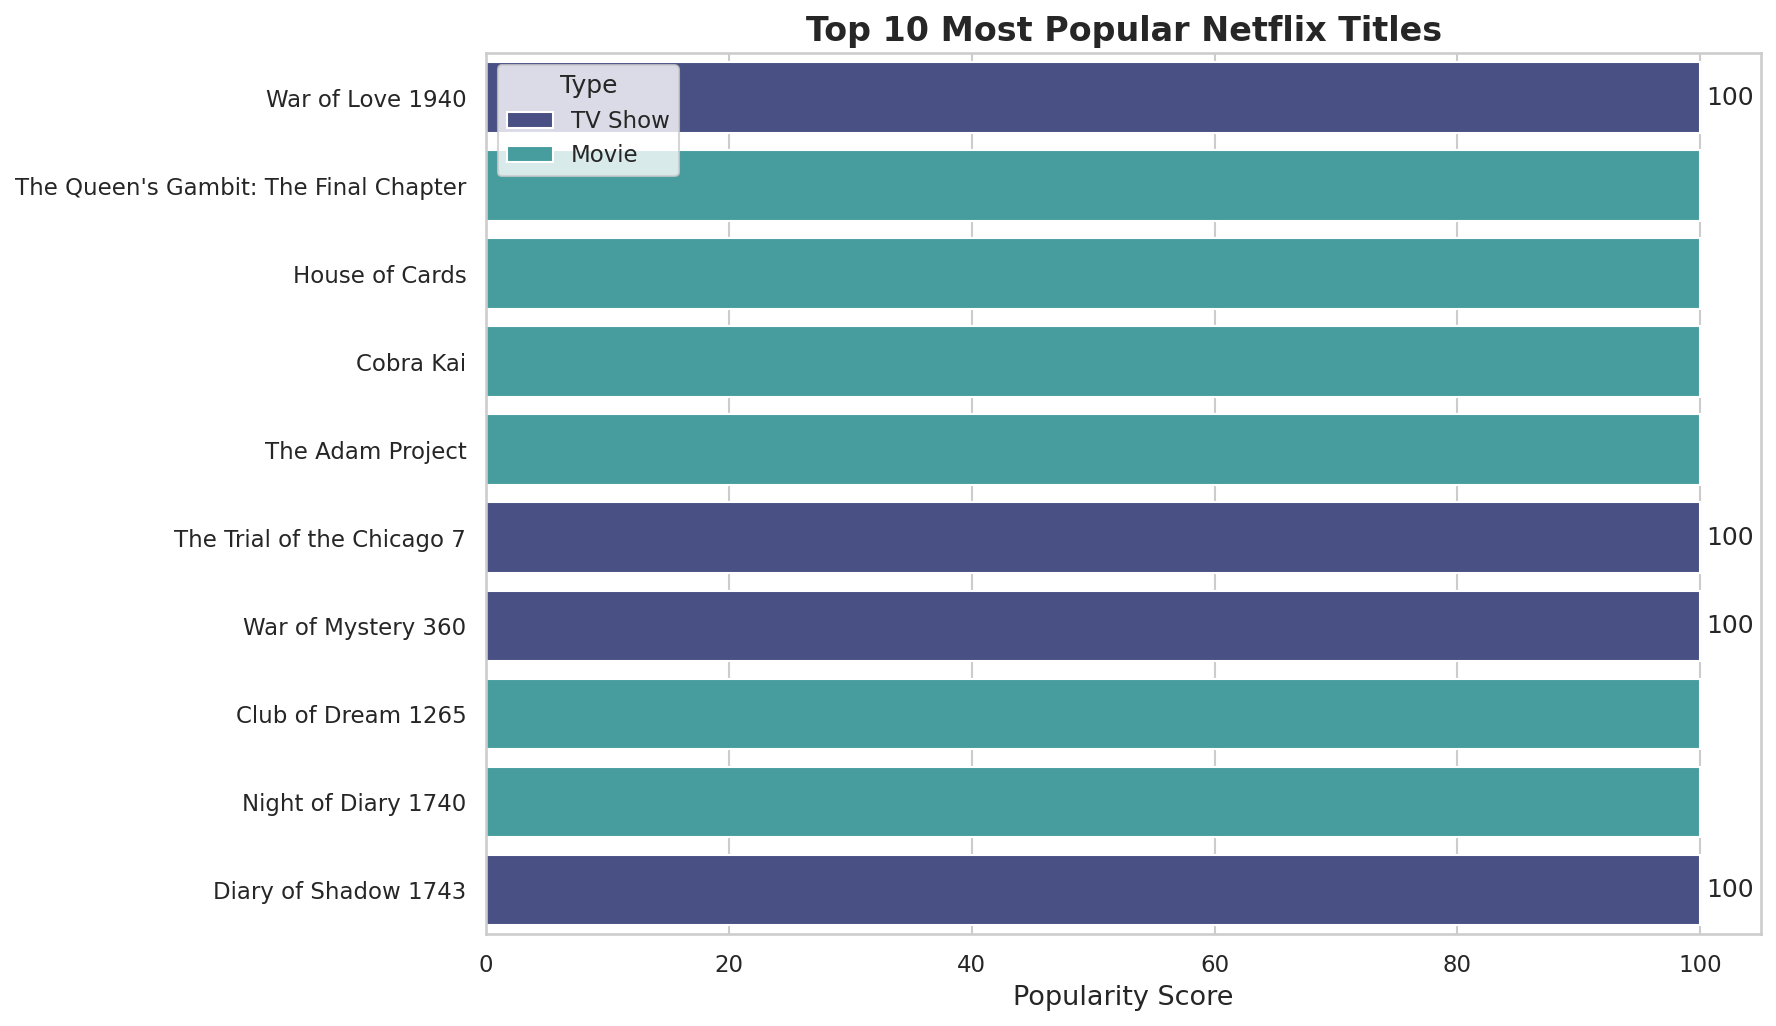

In [16]:
plt.figure(figsize=(12, 7), dpi=150)

ax = sns.barplot(
    data=top10_titles,
    x='popularity_score',
    y='title',
    hue='type',
    palette='mako'
)

ax.bar_label(ax.containers[0], padding=3)

plt.title("Top 10 Most Popular Netflix Titles", fontsize=16, fontweight='bold')
plt.xlabel("Popularity Score", fontsize=13)
plt.ylabel("")
plt.legend(title='Type')
plt.tight_layout()
plt.show()

**Insight:** The top titles help identify the strongest performers in the catalog and whether highly popular content is mostly Movies or TV Shows.

### Question 6: How has Netflix content changed over the years?

This shows how many titles were added to Netflix each year and whether the platform's catalog expanded over time.

In [17]:
year_counts = df.groupby('year_added').size().reset_index(name='title_count')
year_counts

,year_added,title_count
0,2016,96
1,2017,114
2,2018,173
3,2019,202
4,2020,240
5,2021,255
6,2022,311
7,2023,268
8,2024,341


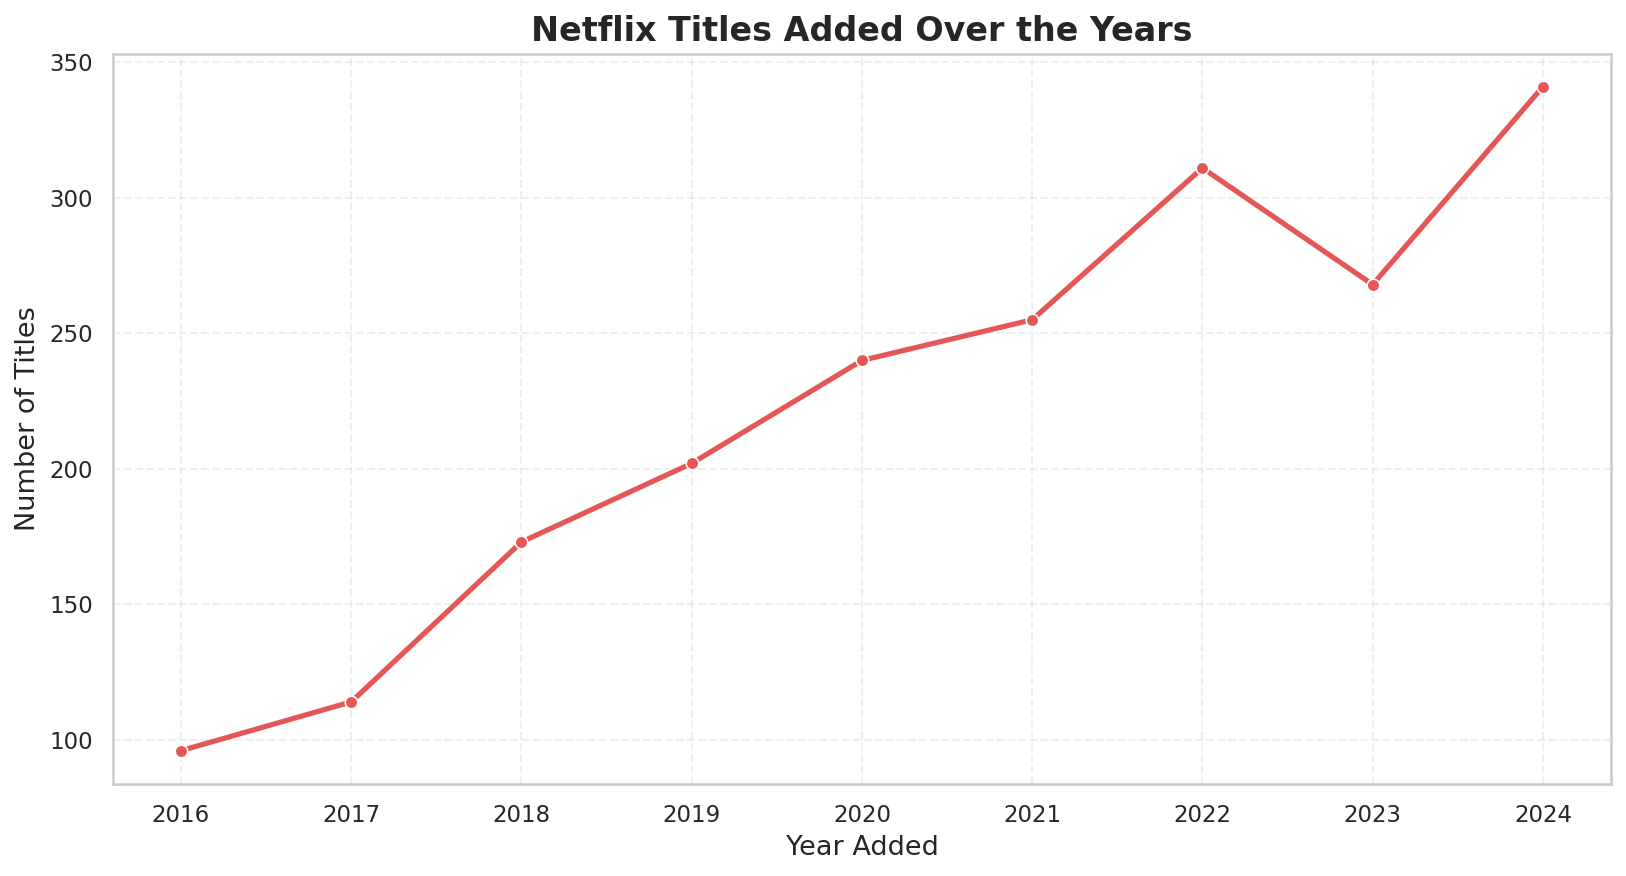

In [18]:
plt.figure(figsize=(11, 6), dpi=150)

sns.lineplot(
    data=year_counts,
    x='year_added',
    y='title_count',
    marker='o',
    linewidth=2.5,
    color='#E45756'
)

plt.title("Netflix Titles Added Over the Years", fontsize=16, fontweight='bold')
plt.xlabel("Year Added", fontsize=13)
plt.ylabel("Number of Titles", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** The year-wise trend shows when Netflix added the most content and whether content growth was consistent or fluctuating.

## 5. Key Insights

- The catalog distribution between Movies and TV Shows gives a high-level view of Netflix's content strategy.
- Genre analysis shows which categories dominate the platform.
- Genre performance analysis compares quantity, average IMDb score, and popularity together.
- Country analysis highlights which regions contribute the most content.
- Popularity analysis identifies the strongest-performing titles in the dataset.
- Year-wise analysis shows how Netflix content additions changed over time.

## 6. Conclusion

This project demonstrates core Python data analysis skills including data cleaning, grouping, aggregation, pivot-style analysis, and visualization using Pandas, Matplotlib, and Seaborn. It is suitable as a first GitHub portfolio project for data analytics.